In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "figure.constrained_layout.use": True,
})

ALGO_SHORT = {
    "ModifiedLogPartitionVarianceGFlowNet": "ModLPV",
    "LogPartitionVarianceGFlowNet": "LPV",
    "TBGFlowNet": "TB",
    "ModifiedTBGFlowNet": "ModTB",
}
ALGO_ORDER = ["TB", "ModTB", "LPV", "ModLPV"]
COLORS = {"TB": "C0", "ModTB": "C1", "LPV": "C2", "ModLPV": "C3"}

sweep_dir = Path("sweep_results")
HP_COLS = ["lr", "beta2", "grad_clip_max_norm"]
CONFIG_COLS = ["environment", "algo"] + HP_COLS  # uniquely identifies a hyperparameter config

# --- Load aggregated timeseries (has HP columns inline) ---
ts = pd.read_csv(sweep_dir / "aggregated_results.csv", low_memory=False)
ts["algo"] = ts["algorithm"].map(ALGO_SHORT)
ts["l1_finite"] = ts["l1_dist"].replace([np.inf, -np.inf], np.nan)

# --- Best L1 per (config, seed) ---
best_l1_per_seed = (
    ts.groupby(CONFIG_COLS + ["seed"])["l1_finite"]
    .min()
    .reset_index(name="best_l1")
)

# --- Aggregate across seeds per config ---
config_stats = (
    best_l1_per_seed.groupby(CONFIG_COLS)["best_l1"]
    .agg(mean_l1="mean", std_l1="std", min_l1="min", n_seeds="count")
    .reset_index()
)

# --- Best config per (algo, env): lowest best-L1 achieved by that config ---
# Selection is by the config's best L1 (not aggregated across seeds).
# Plotting then shows mean ± std across all seeds of that config.
best_configs = config_stats.sort_values("min_l1").groupby(["environment", "algo"]).first().reset_index()

# --- Filter timeseries to best configs (all seeds) ---
ts_best = ts.merge(best_configs[CONFIG_COLS], on=CONFIG_COLS, how="inner")

env_list = sorted(ts["environment"].unique())
n_configs = config_stats.shape[0]

print(f"Timeseries: {ts.shape[0]:,} rows, {n_configs} unique configs, "
      f"{ts['algo'].nunique()} algorithms, {ts['environment'].nunique()} environments")
print(f"Seeds per config: {config_stats['n_seeds'].describe()[['min','mean','max']].to_dict()}")
print(f"Best configs selected: {len(best_configs)} (by best L1 distance; plotted as mean ± std across seeds)")

## Best L1 distance by algorithm and environment

For each (algorithm, environment), we select the hyperparameter configuration that achieved the best L1 distance, then report its mean ± std across seeds.

In [2]:
print("Best L1 distance: mean ± std across seeds (lower = better):")
pivot = best_configs.pivot(index="algo", columns="environment", values=["mean_l1", "std_l1"])
# Format as mean ± std
fmt_df = pivot["mean_l1"].copy()
for env in env_list:
    if env in pivot["mean_l1"].columns and env in pivot["std_l1"].columns:
        fmt_df[env] = pivot["mean_l1"][env].map(lambda x: f"{x:.4f}" if pd.notna(x) else "—") + \
                      " ± " + pivot["std_l1"][env].map(lambda x: f"{x:.4f}" if pd.notna(x) else "")
fmt_df = fmt_df.reindex(ALGO_ORDER)
fmt_df

Best L1 distance: mean ± std across seeds (lower = better):


environment,bitwise_xor,cosine,multiplicative_coprime,original
algo,,,,
TB,1.9174 ± 0.0012,1.4843 ± 0.0006,1.6181 ± 0.1387,1.4255 ± 0.0027
ModTB,1.9759 ± 0.0019,1.9766 ± 0.0017,1.9064 ± 0.0047,1.9585 ± 0.0016
LPV,1.8617 ± 0.0035,1.4783 ± 0.0004,0.3778 ± 0.0016,1.3231 ± 0.0008
ModLPV,1.8719 ± 0.0157,1.4787 ± 0.0003,0.3781 ± 0.0008,1.3322 ± 0.0020


In [3]:
print("Number of seeds for each best config:")
best_configs.pivot(index="algo", columns="environment", values="n_seeds").reindex(ALGO_ORDER).style.format("{:.0f}", na_rep="—")

Number of seeds for each best config:


environment,bitwise_xor,cosine,multiplicative_coprime,original
algo,,,,
TB,1,—,3,—
ModTB,5,1,5,5
LPV,1,1,1,5
ModLPV,5,5,5,1


## L1 distance over training (best config per algorithm)

For each (algorithm, environment), the config with the best L1 distance is selected. All seeds of that config are shown as mean ± std.

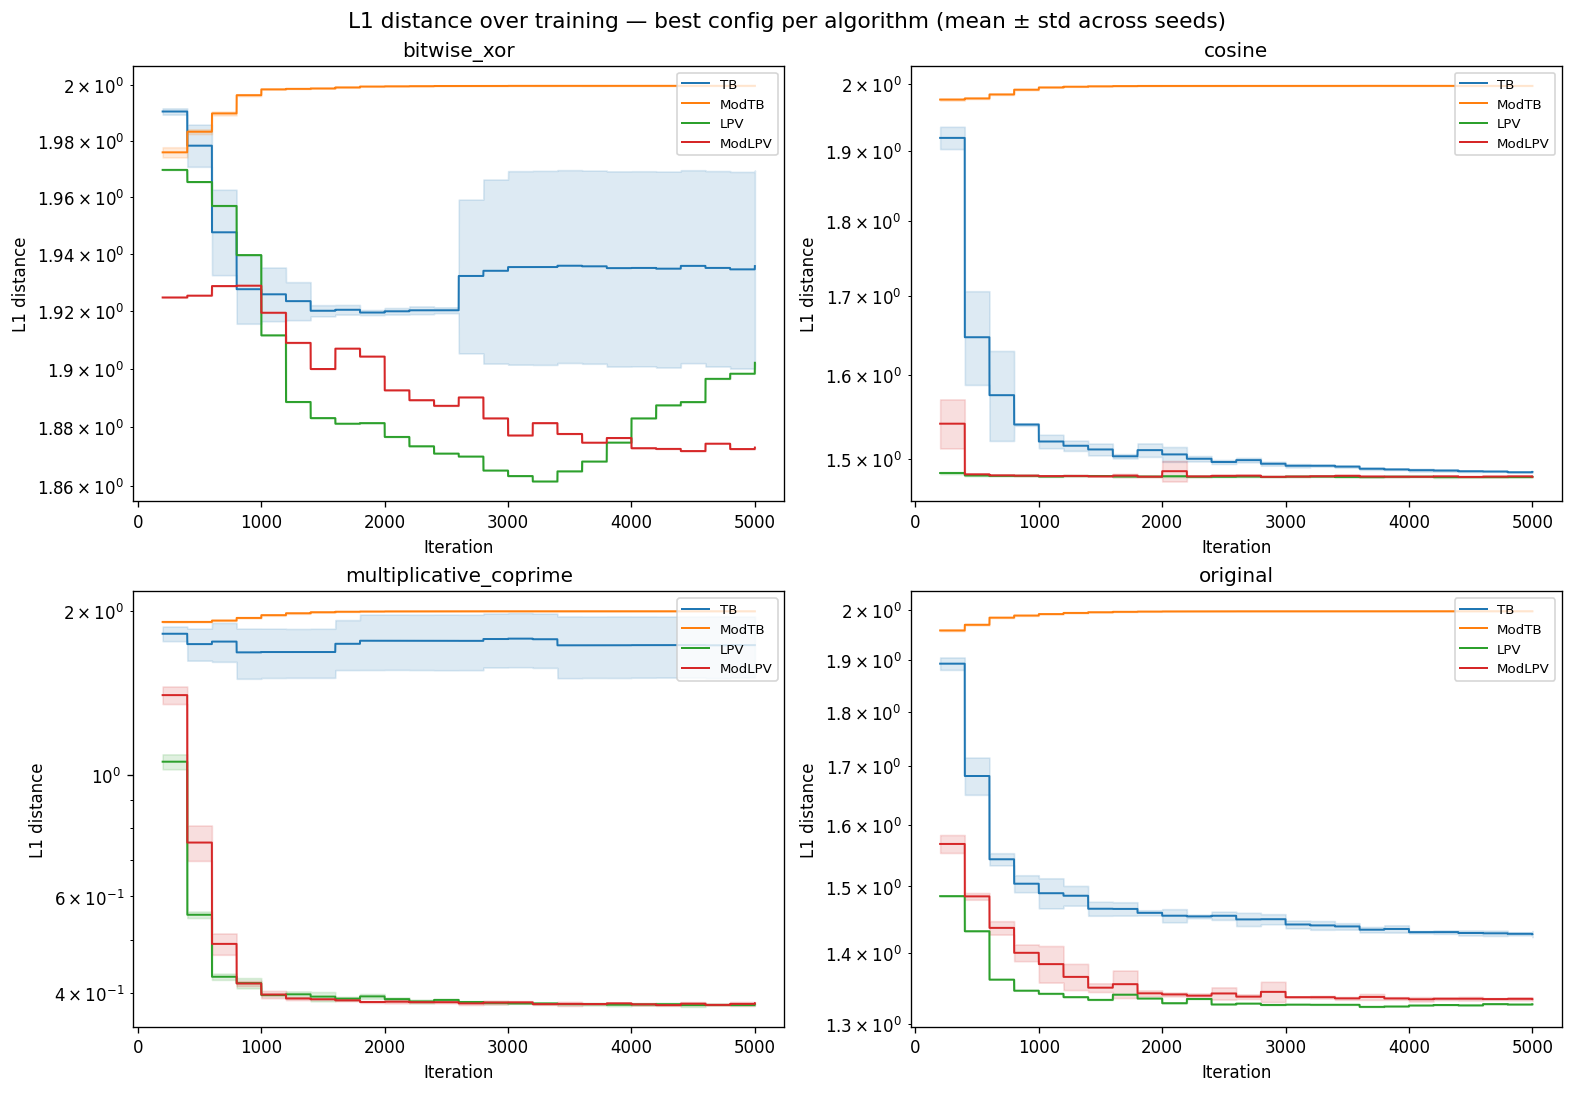

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, env in zip(axes.flat, env_list):
    for algo in ALGO_ORDER:
        ad = ts_best[(ts_best["environment"] == env) & (ts_best["algo"] == algo)].copy()
        if ad.empty:
            continue
        ad = ad[ad["l1_finite"].notna()]
        if ad.empty:
            continue
        # Aggregate across seeds
        grouped = ad.groupby("iteration")["l1_finite"].agg(["mean", "std"])
        ax.plot(grouped.index, grouped["mean"], label=algo, color=COLORS[algo], linewidth=1.2)
        ax.fill_between(grouped.index,
                        grouped["mean"] - grouped["std"],
                        grouped["mean"] + grouped["std"],
                        color=COLORS[algo], alpha=0.15)
    ax.set_title(env)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("L1 distance")
    ax.set_yscale("log")
    ax.legend(loc="upper right")

fig.suptitle("L1 distance over training — best config per algorithm (mean ± std across seeds)", fontsize=13)
plt.show()

## Mode discovery over training (best-L1 runs)

Percentage of modes found over training for the same best-L1 runs selected above, relative to the total number of mode states in each environment.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, env in zip(axes.flat, env_list):
    # Get total mode states for this environment
    env_data = ts_best[ts_best["environment"] == env]
    total_modes = env_data["total_mode_states"].dropna().iloc[0] if not env_data.empty else None

    for algo in ALGO_ORDER:
        ad = env_data[env_data["algo"] == algo]
        if ad.empty:
            continue
        grouped = ad.groupby("iteration")["n_mode_states_found"].agg(["mean", "std"])
        if total_modes and total_modes > 0:
            pct_mean = grouped["mean"] / total_modes * 100
            pct_std = grouped["std"] / total_modes * 100
        else:
            pct_mean = grouped["mean"]
            pct_std = grouped["std"]
        ax.plot(grouped.index, pct_mean, label=algo, color=COLORS[algo], linewidth=1.5)
        ax.fill_between(grouped.index,
                        (pct_mean - pct_std).clip(lower=0),
                        (pct_mean + pct_std).clip(upper=100),
                        color=COLORS[algo], alpha=0.15)
    ax.axhline(100, ls="--", color="gray", alpha=0.4, label="100%")
    title_suffix = f" ({int(total_modes)} modes)" if total_modes else ""
    ax.set_title(f"{env}{title_suffix}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Modes found (%)")
    ax.set_ylim(-2, 105)
    ax.legend(loc="lower right")

fig.suptitle("Mode discovery — best-L1 config per algorithm (mean ± std across seeds)", fontsize=13)
plt.show()

## Loss over training (best-L1 runs)

Loss values are not directly comparable across methods (different constructions), but shown for reference alongside the same best-L1 runs.

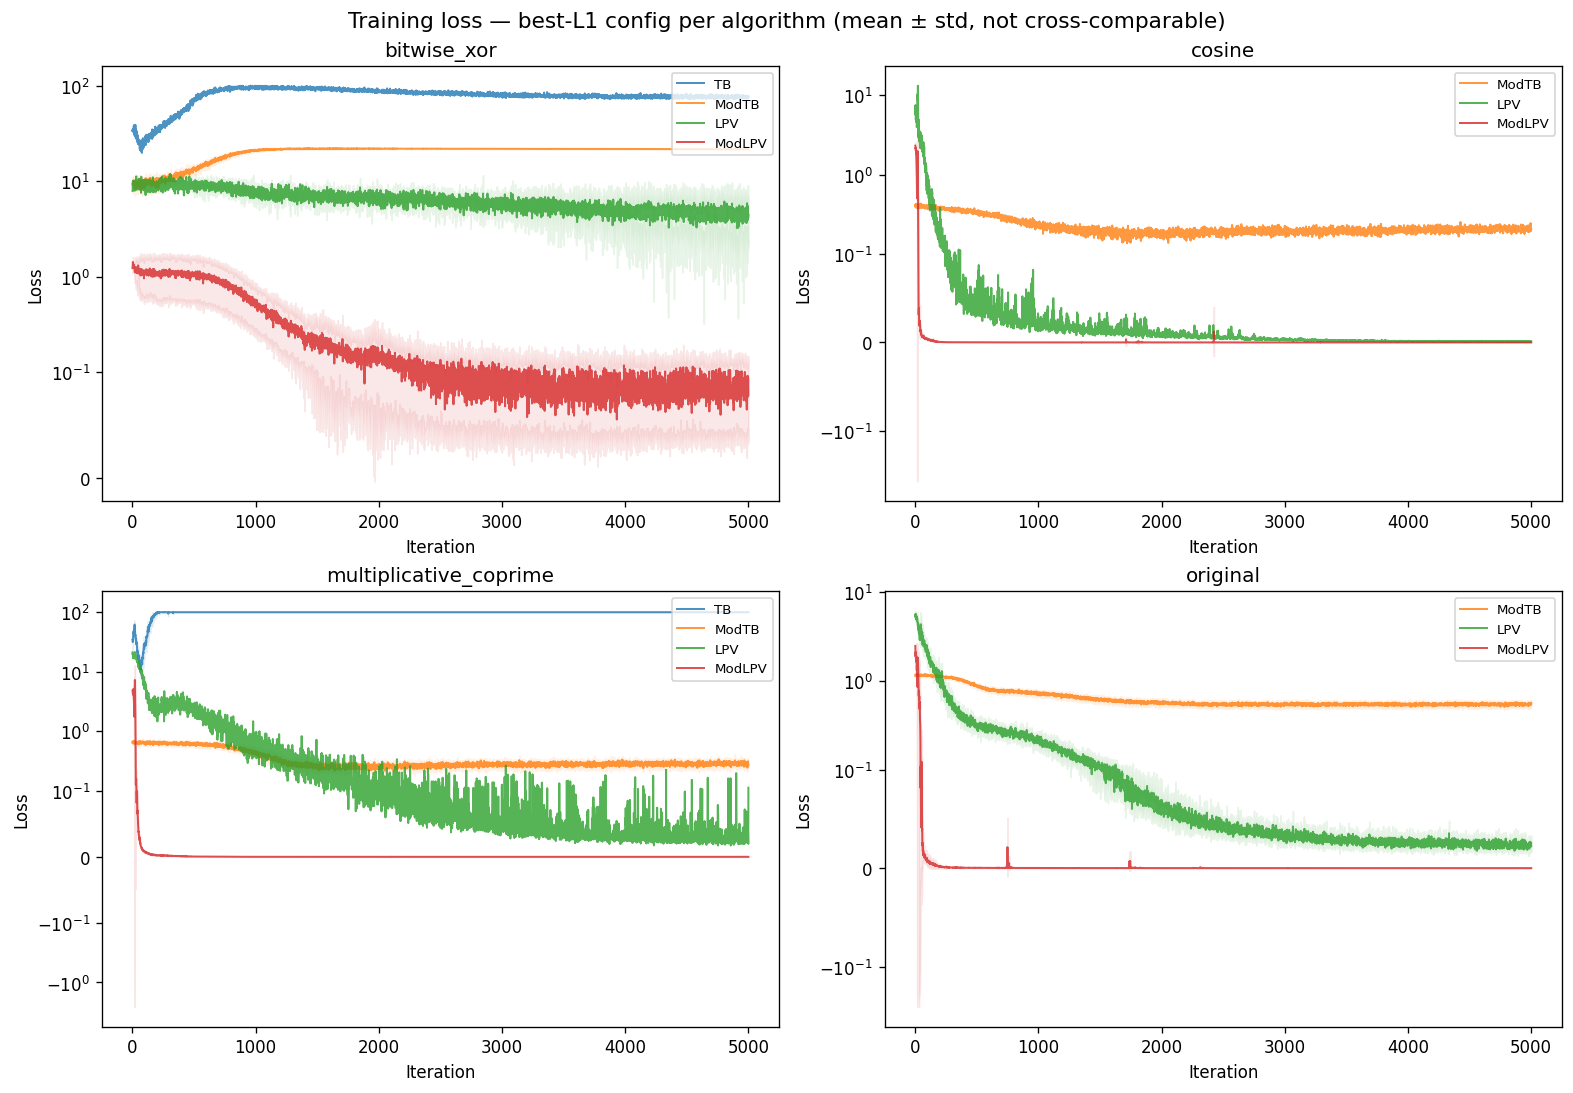

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, env in zip(axes.flat, env_list):
    for algo in ALGO_ORDER:
        ad = ts_best[(ts_best["environment"] == env) & (ts_best["algo"] == algo)]
        if ad.empty:
            continue
        grouped = ad.groupby("iteration")["loss"].agg(["mean", "std"])
        clipped_mean = grouped["mean"].clip(upper=200)
        ax.plot(grouped.index, clipped_mean,
                label=algo, color=COLORS[algo], linewidth=1.2, alpha=0.8)
        ax.fill_between(grouped.index,
                        (clipped_mean - grouped["std"]).clip(lower=-200),
                        (clipped_mean + grouped["std"]).clip(upper=200),
                        color=COLORS[algo], alpha=0.1)
    ax.set_title(env)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_yscale("symlog", linthresh=0.1)
    ax.legend(loc="upper right")

fig.suptitle("Training loss — best-L1 config per algorithm (mean ± std, not cross-comparable)", fontsize=13)
plt.show()

## Hyperparameter sensitivity

For each algorithm, how does the best-case L1 distance vary with each hyperparameter? Each point = best run at that HP value (min across other HP settings).

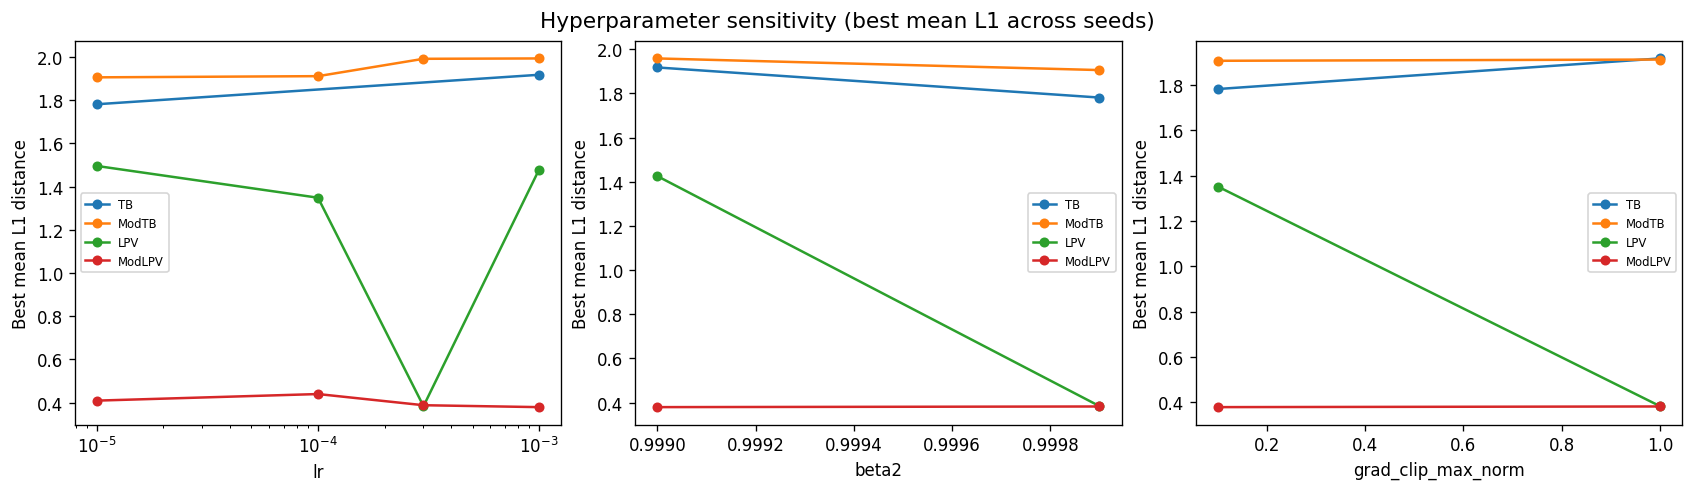

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, hp in zip(axes, HP_COLS):
    for algo in ALGO_ORDER:
        sub = config_stats[config_stats["algo"] == algo]
        if sub.empty or sub[hp].isna().all():
            continue
        grouped = sub.groupby(hp)["mean_l1"].min()
        ax.plot(grouped.index, grouped.values, "o-", label=algo, color=COLORS[algo], markersize=5)
    ax.set_xlabel(hp)
    ax.set_ylabel("Best mean L1 distance")
    if hp == "lr":
        ax.set_xscale("log")
    ax.legend(fontsize=7)

fig.suptitle("Hyperparameter sensitivity (best mean L1 across seeds)", fontsize=13)
plt.show()

## Best hyperparameters per algorithm x environment

In [8]:
best_detail = best_configs[["algo", "environment", "mean_l1", "std_l1", "n_seeds"] + HP_COLS].copy()
best_detail = best_detail.sort_values(["environment", "mean_l1"])
best_detail.style.format(
    {"mean_l1": "{:.4f}", "std_l1": "{:.4f}", "lr": "{:.0e}", "n_seeds": "{:.0f}"}, na_rep="—"
).background_gradient(subset=["mean_l1"], cmap="RdYlGn_r")

,algo,environment,mean_l1,std_l1,n_seeds,lr,beta2,grad_clip_max_norm
0,LPV,bitwise_xor,1.8640,—,1,1e-05,0.999900,1.000000
1,ModLPV,bitwise_xor,1.9059,0.0210,5,1e-05,0.999000,1.000000
3,TB,bitwise_xor,1.9163,—,1,1e-05,0.999900,1.000000
2,ModTB,bitwise_xor,1.9759,0.0018,5,1e-05,0.999000,0.100000
4,LPV,cosine,1.4783,0.0001,1,3e-04,0.999900,1.000000
5,ModLPV,cosine,1.4787,0.0002,5,1e-03,0.999900,0.100000
6,ModTB,cosine,1.9785,0.0006,1,1e-05,0.999900,0.100000
8,ModLPV,multiplicative_coprime,0.3794,0.0009,5,1e-03,0.999000,0.100000
7,LPV,multiplicative_coprime,0.3839,0.0129,1,3e-04,0.999900,1.000000
10,TB,multiplicative_coprime,1.7814,0.0598,3,1e-05,0.999900,0.100000


## Training stability: ModLPV vs LPV

ModLPV exhibits loss spikes during training, especially at higher learning rates. The instability is predominantly lr-driven — at lr <= 1e-4, ModLPV is comparably stable to LPV.

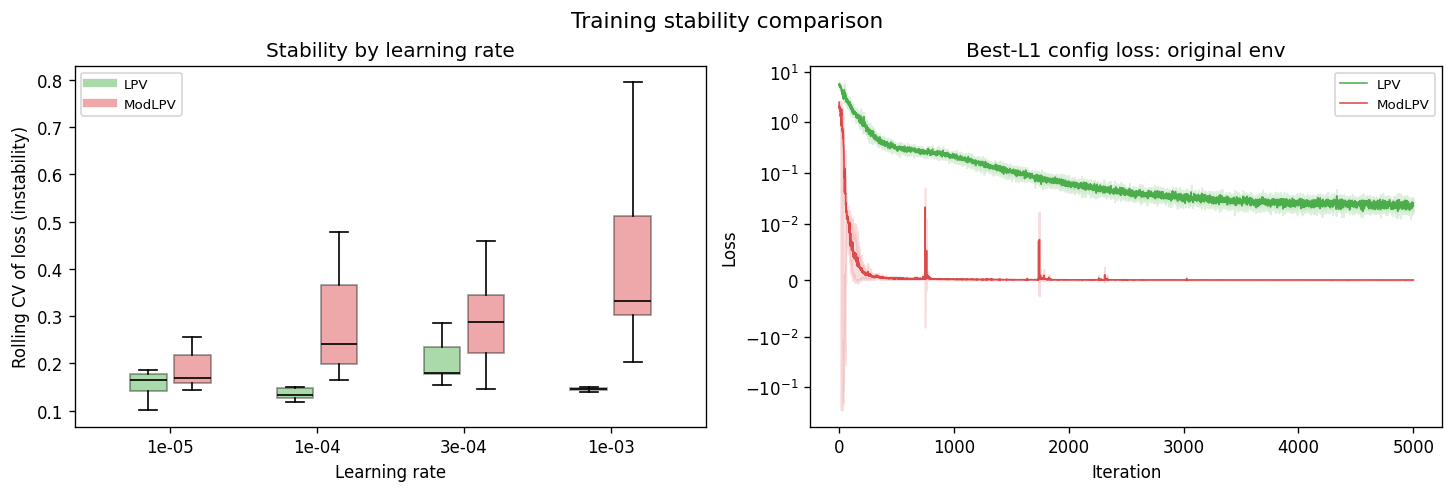

In [9]:
# Compute rolling coefficient of variation (std/mean) over 100-iter windows
def _rolling_cv(g):
    loss = g.sort_values("iteration")["loss"]
    rm = loss.rolling(100, min_periods=20).mean()
    rs = loss.rolling(100, min_periods=20).std()
    return (rs / rm.clip(lower=1e-8)).mean()

stability = (
    ts[ts["algo"].isin(["ModLPV", "LPV"])]
    .groupby(["algo", "environment", "seed"] + HP_COLS)
    .apply(_rolling_cv, include_groups=False)
    .reset_index(name="cv")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: CV by learning rate
for ax_i, algo in enumerate(["LPV", "ModLPV"]):
    sub = stability[stability["algo"] == algo]
    lr_vals = sorted(sub["lr"].unique())
    bp_data = [sub.loc[sub["lr"] == lr, "cv"].dropna().values for lr in lr_vals]
    bp = axes[0].boxplot(bp_data, positions=np.arange(len(bp_data)) + ax_i * 0.3 - 0.15,
                         widths=0.25, patch_artist=True, showfliers=False,
                         boxprops=dict(facecolor=COLORS[algo], alpha=0.4),
                         medianprops=dict(color="black"))
    axes[0].plot([], [], color=COLORS[algo], label=algo, linewidth=5, alpha=0.4)

lr_labels = [f"{lr:.0e}" for lr in sorted(stability["lr"].unique())]
axes[0].set_xticks(range(len(lr_labels)))
axes[0].set_xticklabels(lr_labels)
axes[0].set_xlabel("Learning rate")
axes[0].set_ylabel("Rolling CV of loss (instability)")
axes[0].legend()
axes[0].set_title("Stability by learning rate")

# Right: best-config loss curves overlaid for ModLPV vs LPV (original env, mean ± std)
for algo in ["LPV", "ModLPV"]:
    ad = ts_best[(ts_best["environment"] == "original") & (ts_best["algo"] == algo)]
    if ad.empty:
        continue
    grouped = ad.groupby("iteration")["loss"].agg(["mean", "std"])
    axes[1].plot(grouped.index, grouped["mean"], label=algo, color=COLORS[algo], linewidth=1, alpha=0.8)
    axes[1].fill_between(grouped.index,
                         grouped["mean"] - grouped["std"],
                         grouped["mean"] + grouped["std"],
                         color=COLORS[algo], alpha=0.15)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Loss")
axes[1].set_yscale("symlog", linthresh=0.01)
axes[1].set_title("Best-L1 config loss: original env")
axes[1].legend()

fig.suptitle("Training stability comparison", fontsize=13)
plt.show()